# Silhouette Score :

The silhouette score is a cluster analysis metric that measures how well-separated and cohesive clusters are, ranging from -1 to +1.

Silhouette refers to a method of interpretion and validataion of consistency within clusters of data.

Silhouette Coefficient or silhouette score is a metric usedd to calculate the goodness of a clusteering technique.

its value range from -1 to 1


In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [33]:
dataset = pd.read_csv("Iris_raw.csv")
dataset.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


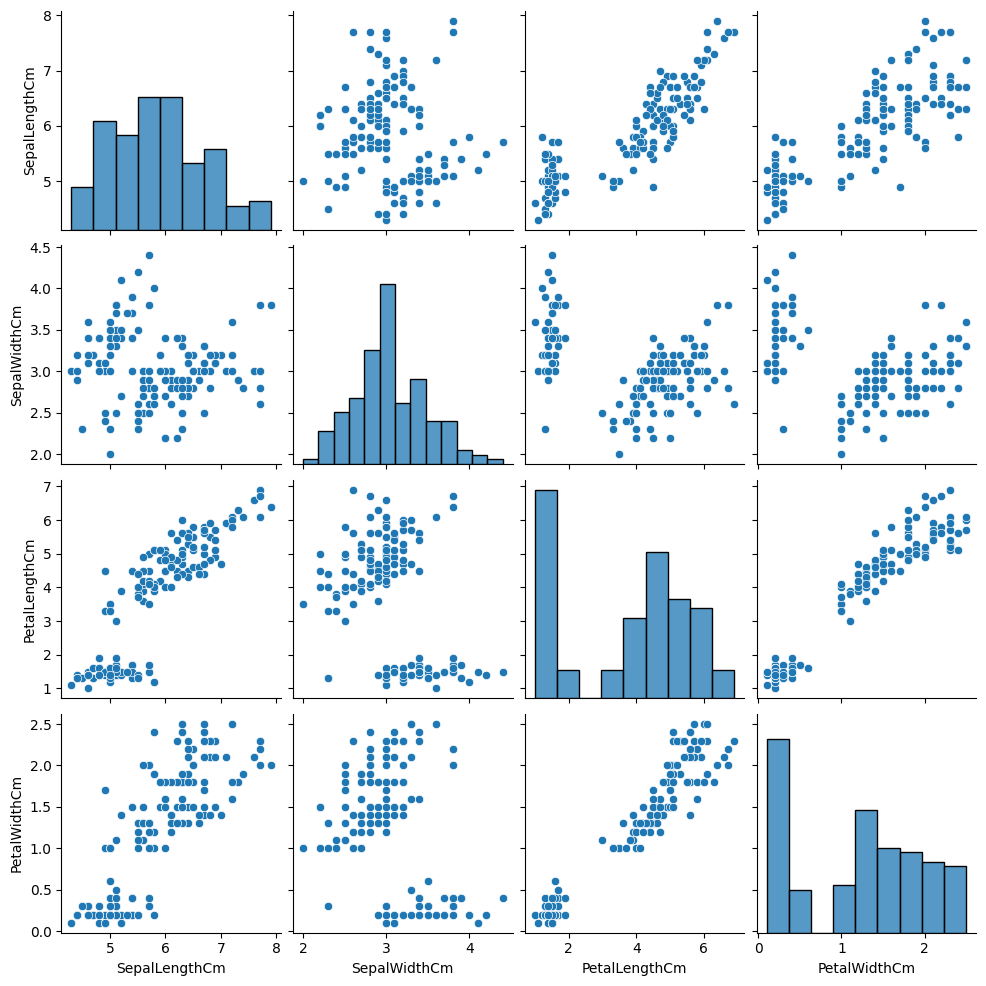

In [34]:
sns.pairplot(data=dataset)
plt.show()

In [35]:
from sklearn.cluster import KMeans

In [36]:
wcss = []

for i in range(2,21):
    km = KMeans(n_clusters=i,init="k-means++")
    km.fit(dataset)
    wcss.append(km.inertia_)

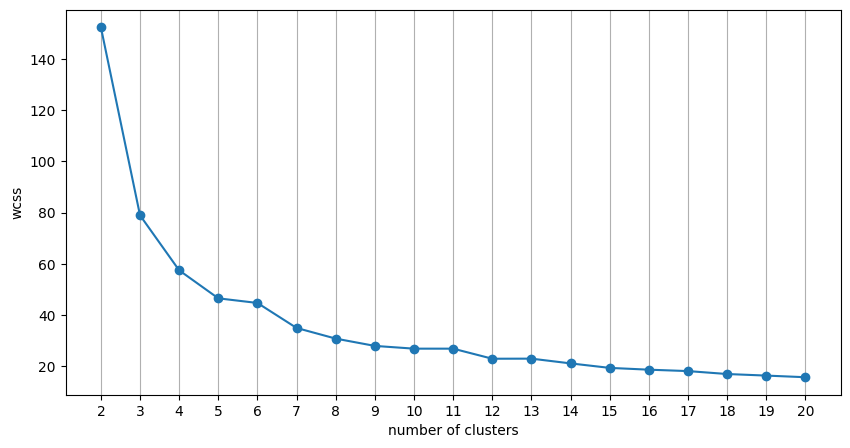

In [37]:
plt.figure(figsize=(10,5))
plt.plot([i for i in range(2,21)],wcss,marker = "o")
plt.xlabel("number of clusters")
plt.xticks([i for i in range(2,21)])
plt.ylabel("wcss")
plt.grid(axis="x")
plt.show()


In [38]:
kmn = KMeans(n_clusters=3)

dataset["Predict_Output"] = kmn.fit_predict(dataset)

In [39]:
dataset.head(20)

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Predict_Output
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
5,5.4,3.9,1.7,0.4,0
6,4.6,3.4,1.4,0.3,0
7,5.0,3.4,1.5,0.2,0
8,4.4,2.9,1.4,0.2,0
9,4.9,3.1,1.5,0.1,0


Silhoutte_Score :

In [40]:
from sklearn.metrics import silhouette_score

In [41]:
silhouette_score(dataset,labels=kmn.labels_ ) 


0.6218780254335335

/tmp/ipykernel_69081/598841708.py:2: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc=5)


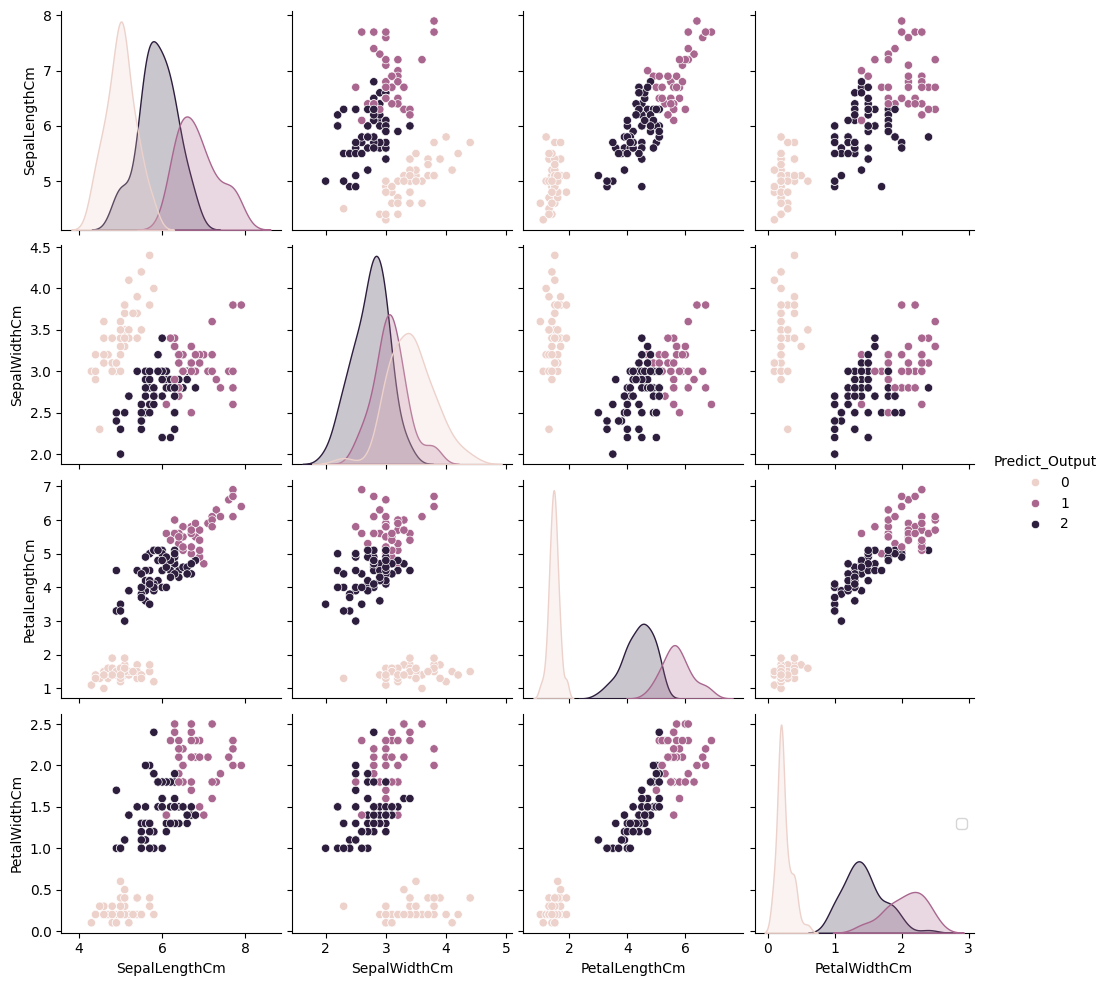

In [42]:
sns.pairplot(data=dataset ,hue="Predict_Output")
plt.legend(loc=5)
plt.show()

Evaluating silhouette_score of clusters between 2 and 21 to check which results better


In [43]:
ss = []
no_cluster = [j for j in range(2,21) ]  # 2,3,4,5,6,,,20
for i in range(2,21):
    km1 = KMeans(n_clusters=i)
    km1.fit(dataset)
    ss.append(silhouette_score(dataset,km1.labels_))

Graph :  ss vs number of cluster  => to check which is the best number of cluster

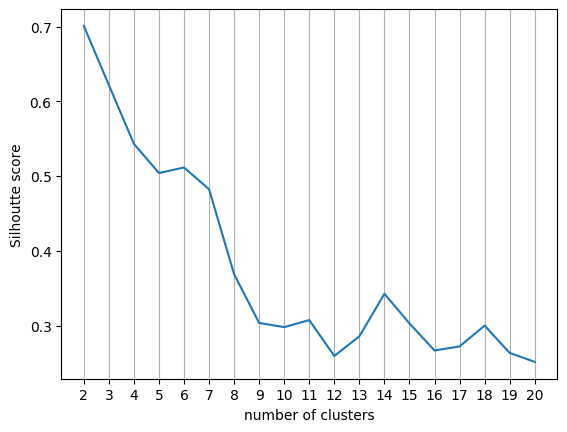

In [44]:
plt.plot(no_cluster,ss)
plt.xlabel("number of clusters")
plt.ylabel("Silhoutte score")
plt.xticks(no_cluster)
plt.grid(axis="x")
plt.show()

In [45]:
# graph is showing best number of cluster is 3